## 1. Import Libraries and Load Data

In [6]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Add models directory to path
sys.path.insert(0, os.path.abspath('../models'))
sys.path.insert(0, os.path.abspath('..'))

# Import custom models
from models.knn import KNN
from models.decision_tree import DecisionTree
from models.random_forest import RandomForest

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [7]:
# Load the merged dataset
data_path = '../results/fires_merged_all_features.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (5978, 42)

First few rows:


,longitude,latitude,class,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring,prec_summer,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
0,6.69080,32.52750,1,-0.924385,1.119777,0.322710,-1.038006,1.609276,1.537259,-1.102612,...,0.20174,-2.639608,-1.930200,-1.686121,0.223455,-1.504578,-0.131095,-1.514668,-0.433614,0.264563
1,7.24306,34.57001,1,-0.862140,0.687169,0.788114,-0.761866,0.987929,1.031414,-0.456765,...,-0.15670,0.906968,1.381428,1.393887,1.029051,-0.361163,-0.131095,2.554286,-0.541156,0.264563
2,0.08182,34.04139,1,-0.646643,-0.709538,-0.729820,-0.259878,-0.233630,-0.584821,1.017926,...,0.38096,-0.541634,-0.037841,2.933891,0.805274,-0.361163,-0.131095,-0.605405,-0.433614,0.264563
3,7.73276,36.30403,1,1.033662,-1.710718,-1.016222,1.344364,-1.303022,-1.540990,1.294653,...,0.38096,-0.042116,1.381428,1.393887,0.984295,-0.361163,0.883965,1.622291,1.502144,0.264563
4,8.12982,36.57864,1,2.013030,-0.499414,0.243949,1.753614,-0.783120,-0.745210,0.938032,...,0.38096,-0.042116,1.381428,1.393887,0.984295,-0.361163,0.883965,1.622291,1.502144,0.264563


## 2. Data Exploration

In [8]:
# Dataset information
print("Dataset Info:")
print("="*80)
print(f"Total samples: {len(df)}")
print(f"Total features: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum().sum())

Dataset Info:
Total samples: 5978
Total features: 42

Column names:
['longitude', 'latitude', 'class', 'prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn', 'elevation', 'slope', 'aspect', 'roughness', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']

Data types:
longitude        float64
latitude         float64
class              int64
prec_winter      float64
tmax_winter      float64
tmin_winter      float64
prec_spring      float64
tmax_spring      float64
tmin_spring      float64
prec_summer      float64
tmax_summer      float64
tmin_summer      float64
prec_autumn      float64
tmax_autumn      float64
tmin_autumn      float64
elevation        float64
s

Class Distribution:
class
1    4982
0     996
Name: count, dtype: int64

Class proportions:
class
1    0.833389
0    0.166611
Name: proportion, dtype: float64


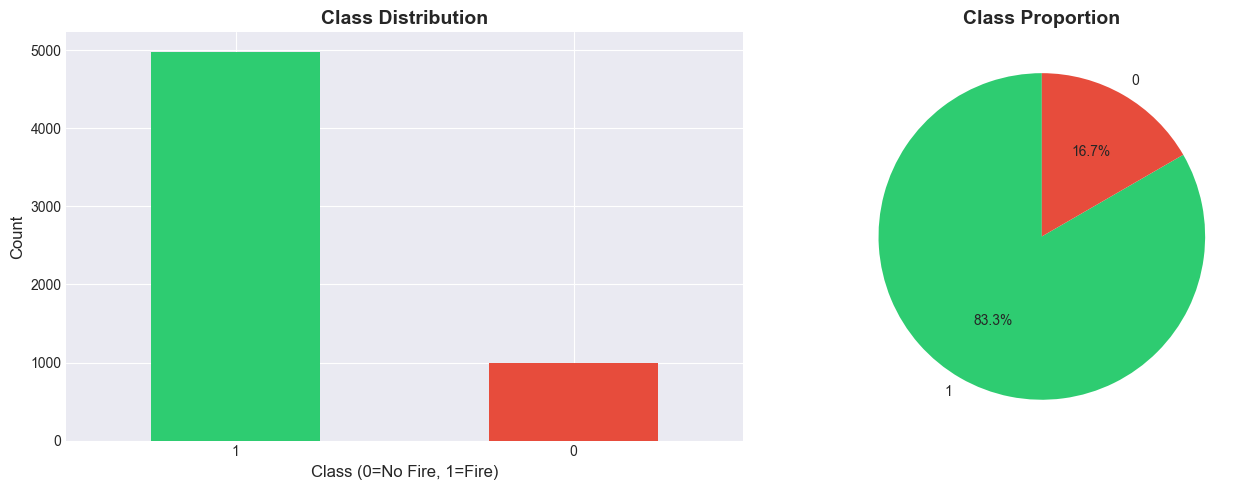

In [9]:
# Class distribution
print("Class Distribution:")
print("="*80)
class_counts = df['class'].value_counts()
print(class_counts)
print(f"\nClass proportions:")
print(df['class'].value_counts(normalize=True))

# Visualize class distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Class (0=No Fire, 1=Fire)', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Pie chart
class_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                   colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [10]:
# Statistical summary
print("Statistical Summary:")
print("="*80)
df.describe()

Statistical Summary:


,longitude,latitude,class,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring,prec_summer,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
count,5978.000000,5978.000000,5978.000000,5.978000e+03,5.978000e+03,5.978000e+03,5.978000e+03,5.978000e+03,5.978000e+03,5.978000e+03,...,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000
mean,5.168845,34.989426,0.833389,3.328069e-17,-4.160086e-16,1.248026e-17,-2.139473e-17,5.289253e-17,-3.856994e-16,3.565788e-18,...,0.201321,0.126440,0.596361,0.687736,0.742588,-0.433081,0.317175,0.877259,0.496181,0.291151
std,3.317364,1.691835,0.372659,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,1.000084e+00,...,0.590127,1.059389,1.080394,1.033675,0.401942,0.388454,0.981659,1.358195,1.079538,0.770409
min,-2.181140,32.009160,0.000000,-1.019372e+00,-3.552394e+00,-2.627237e+00,-1.245784e+00,-2.182206e+00,-2.885796e+00,-1.316852e+00,...,-1.948901,-2.639608,-1.930200,-1.686121,-2.148575,-1.504578,-1.146155,-1.514668,-0.756240,-1.463056
25%,3.083687,33.312670,1.000000,-9.234832e-01,-6.786379e-01,-6.725394e-01,-9.935400e-01,-7.281706e-01,-6.280025e-01,-1.036554e+00,...,-0.156700,-0.042116,-0.274386,-0.146117,0.223455,-0.361163,-0.131095,-0.605405,-0.433614,0.264563
50%,5.974240,35.754465,1.000000,-1.440639e-01,1.000574e-01,3.656699e-01,-2.605696e-01,-2.632176e-01,-1.715087e-01,-2.454253e-01,...,0.201740,-0.042116,1.302580,1.320553,0.984295,-0.361163,-0.131095,1.508633,-0.110987,0.264563
75%,7.202245,36.504427,1.000000,7.958242e-01,7.350648e-01,7.666335e-01,8.886678e-01,7.300916e-01,7.353100e-01,8.630476e-01,...,0.380960,0.906968,1.381428,1.393887,1.029051,-0.361163,0.883965,1.622291,1.502144,0.264563
max,11.110350,37.323460,1.000000,3.279905e+00,1.614187e+00,2.177166e+00,2.856328e+00,2.099590e+00,1.876544e+00,2.931810e+00,...,2.890041,1.706197,2.800697,3.007224,1.029051,3.069082,3.929144,3.304429,2.792650,1.992183


## 3. Data Preprocessing

In [15]:
# Separate features and target
X = df.drop(['longitude', 'latitude', 'class'], axis=1)
y = df['class']

# Identify numeric and non-numeric columns
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nData types:")
print(X.dtypes.value_counts())

# Check for non-numeric columns
non_numeric_cols = X.select_dtypes(include=['object']).columns.tolist()
if non_numeric_cols:
    print(f"\n⚠️ Non-numeric columns found: {non_numeric_cols}")
    print(f"Dropping non-numeric columns...")
    X = X.select_dtypes(include=[np.number])
    print(f"✅ Dropped {len(non_numeric_cols)} non-numeric columns")

print(f"\nFinal feature shape: {X.shape}")
print(f"Feature names ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (5978, 39)
Target shape: (5978,)

Data types:
float64    38
object      1
Name: count, dtype: int64

⚠️ Non-numeric columns found: ['TEXTURE_SOTER']
Dropping non-numeric columns...
✅ Dropped 1 non-numeric columns

Final feature shape: (5978, 38)
Feature names (38):
['prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn', 'elevation', 'slope', 'aspect', 'roughness', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']


In [16]:
# Handle missing values if any
if X.isnull().sum().sum() > 0:
    print("⚠️ Missing values detected. Filling with mean values...")
    X = X.fillna(X.mean())
    print("✅ Missing values handled")
else:
    print("✅ No missing values in features")

✅ No missing values in features


In [17]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Split:")
print("="*80)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Data Split:
Training set: 4782 samples
Test set: 1196 samples

Training set class distribution:
class
1    3985
0     797
Name: count, dtype: int64

Test set class distribution:
class
1    997
0    199
Name: count, dtype: int64


In [18]:
# Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print(f"\nScaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

✅ Features scaled using StandardScaler

Scaled training set shape: (4782, 38)
Scaled test set shape: (1196, 38)


## 4. Model Training

### 4.1 K-Nearest Neighbors (KNN)

In [19]:
print("Training K-Nearest Neighbors (KNN) Model...")
print("="*80)

# Train KNN with k=5
knn_model = KNN(k=5, distance_metric='euclidean')
knn_model.fit(X_train_scaled, y_train.values)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

print("✅ KNN model trained successfully!")

Training K-Nearest Neighbors (KNN) Model...
✅ KNN model trained successfully!
✅ KNN model trained successfully!


### 4.2 Decision Tree

In [20]:
print("Training Decision Tree Model...")
print("="*80)

# Train Decision Tree
dt_model = DecisionTree(max_depth=10, min_samples_split=5, min_samples_leaf=2)
dt_model.fit(X_train_scaled, y_train.values)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

print("✅ Decision Tree model trained successfully!")

Training Decision Tree Model...
✅ Decision Tree model trained successfully!
✅ Decision Tree model trained successfully!


### 4.3 Random Forest

In [21]:
print("Training Random Forest Model...")
print("="*80)

# Train Random Forest
rf_model = RandomForest(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train.values)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("✅ Random Forest model trained successfully!")

Training Random Forest Model...
✅ Random Forest model trained successfully!
✅ Random Forest model trained successfully!


## 5. Model Evaluation

In [22]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate model performance with various metrics
    """
    print(f"\n{model_name} Performance:")
    print("="*80)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Fire', 'Fire']))
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [23]:
# Evaluate all models
results = []

results.append(evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors"))
results.append(evaluate_model(y_test, y_pred_dt, "Decision Tree"))
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))


K-Nearest Neighbors Performance:
Accuracy:  0.8963
Precision: 0.9130
Recall:    0.9679
F1-Score:  0.9396

Classification Report:
              precision    recall  f1-score   support

     No Fire       0.77      0.54      0.63       199
        Fire       0.91      0.97      0.94       997

    accuracy                           0.90      1196
   macro avg       0.84      0.75      0.79      1196
weighted avg       0.89      0.90      0.89      1196


Decision Tree Performance:
Accuracy:  0.9105
Precision: 0.9354
Recall:    0.9589
F1-Score:  0.9470

Classification Report:
              precision    recall  f1-score   support

     No Fire       0.76      0.67      0.71       199
        Fire       0.94      0.96      0.95       997

    accuracy                           0.91      1196
   macro avg       0.85      0.81      0.83      1196
weighted avg       0.91      0.91      0.91      1196


Random Forest Performance:
Accuracy:  0.8988
Precision: 0.9048
Recall:    0.9819
F1-Score: 

In [24]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')

print("\nModel Comparison Summary:")
print("="*80)
print(results_df)

# Find best model
best_model = results_df['f1_score'].idxmax()
print(f"\n🏆 Best Model: {best_model} (F1-Score: {results_df.loc[best_model, 'f1_score']:.4f})")


Model Comparison Summary:
                     accuracy  precision    recall  f1_score
model                                                       
K-Nearest Neighbors  0.896321   0.912961  0.967904  0.939630
Decision Tree        0.910535   0.935421  0.958877  0.947003
Random Forest        0.898829   0.904806  0.981946  0.941799

🏆 Best Model: Decision Tree (F1-Score: 0.9470)


## 6. Visualization

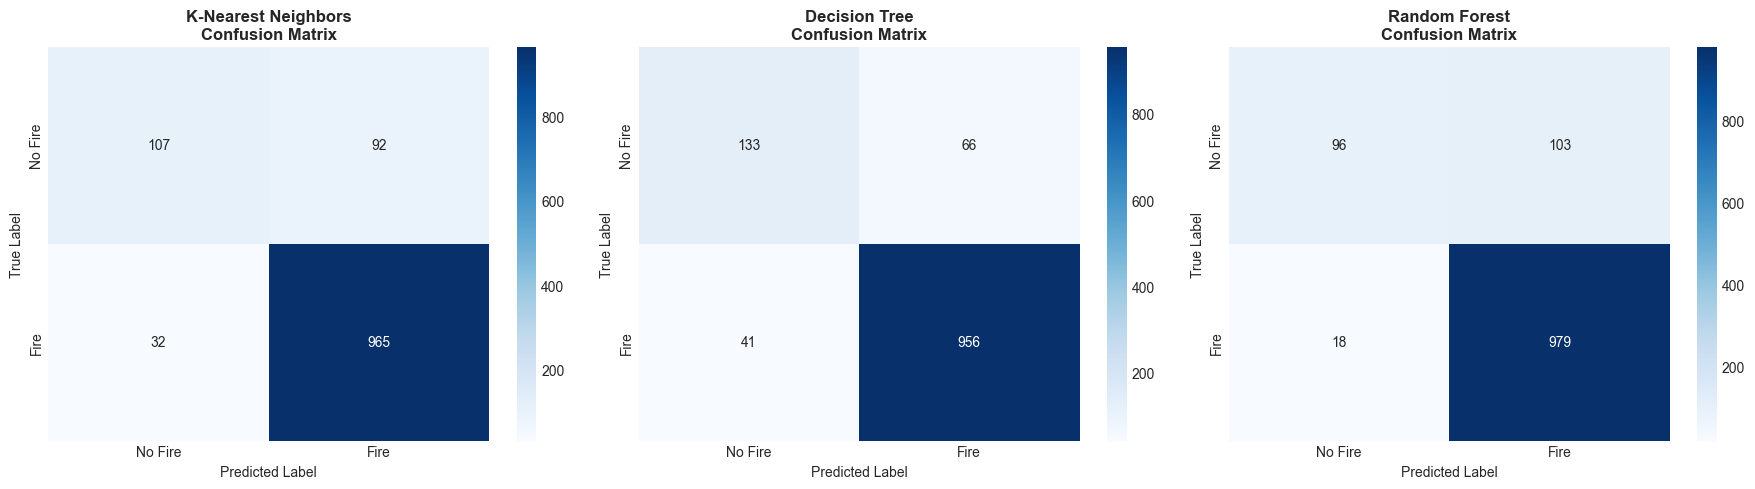

In [25]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    (y_pred_knn, "K-Nearest Neighbors"),
    (y_pred_dt, "Decision Tree"),
    (y_pred_rf, "Random Forest")
]

for idx, (y_pred, model_name) in enumerate(models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Fire', 'Fire'],
                yticklabels=['No Fire', 'Fire'])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

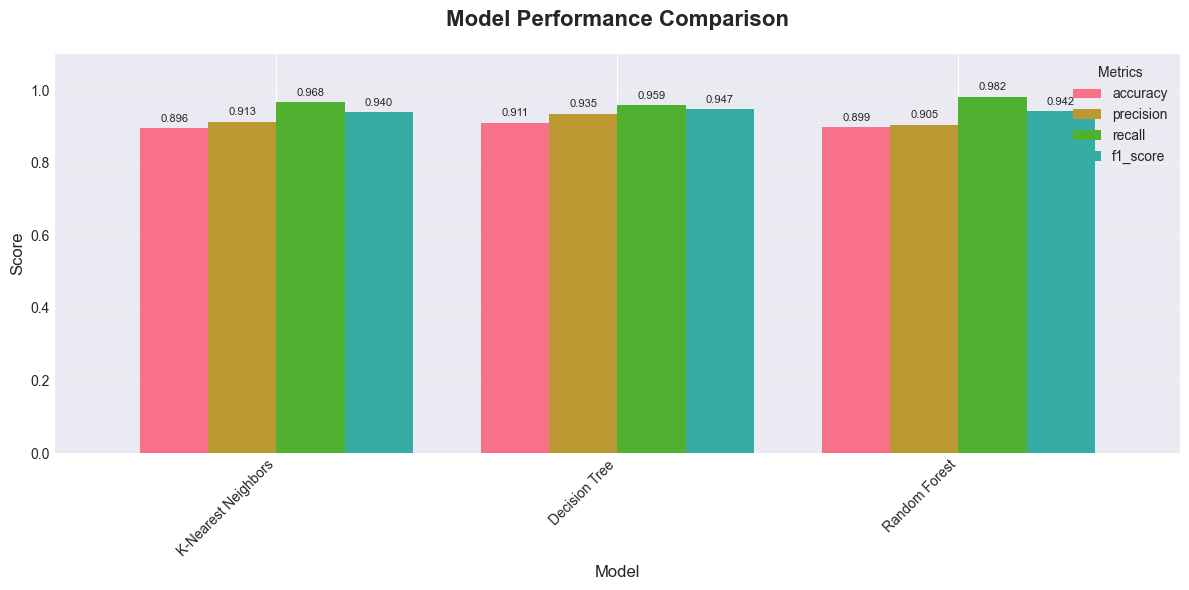

In [26]:
# Plot metrics comparison
fig, ax = plt.subplots(figsize=(12, 6))

results_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Metrics', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

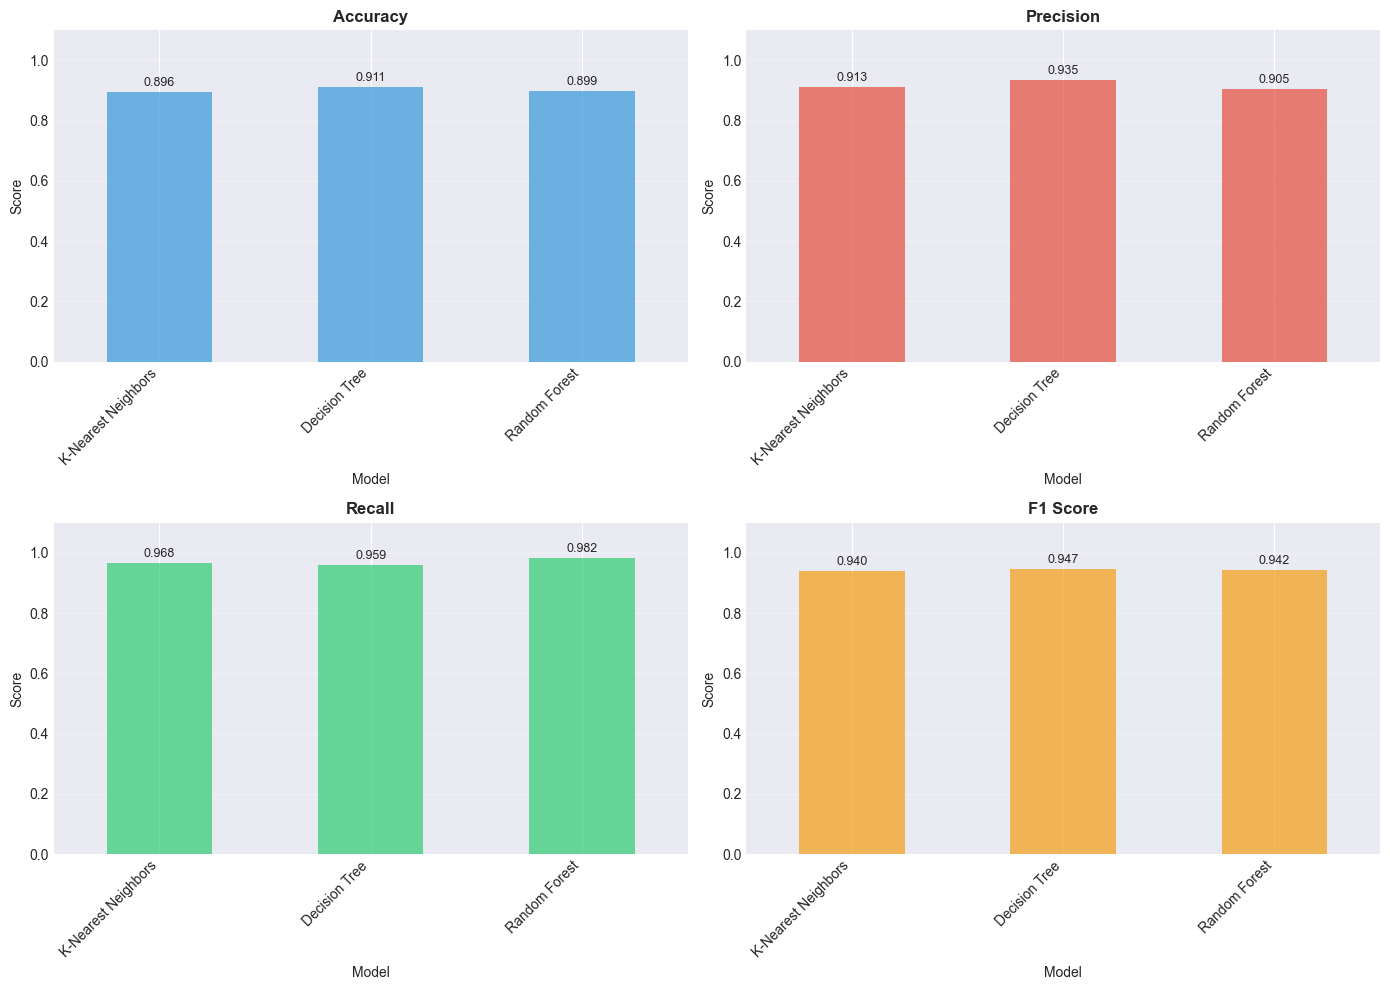

In [27]:
# Plot metric-wise comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    results_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.7)
    ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Feature Importance (Random Forest)

In [28]:
# Get feature importance from Random Forest
try:
    feature_importance = rf_model.feature_importances()
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print("="*80)
    print(importance_df.head(20))
    
    # Plot top 20 features
    fig, ax = plt.subplots(figsize=(12, 8))
    top_features = importance_df.head(20)
    ax.barh(range(len(top_features)), top_features['importance'], color='#3498db', alpha=0.7)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except AttributeError:
    print("⚠️ Feature importance not available for this Random Forest implementation")

⚠️ Feature importance not available for this Random Forest implementation


## 8. Summary and Conclusions

In [29]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\nDataset: {len(df)} samples, {len(X.columns)} features")
print(f"Train/Test Split: {len(X_train)}/{len(X_test)} samples")

print("\nModel Performance Summary:")
print(results_df)

print(f"\n🏆 Best Model: {best_model}")
print(f"   - Accuracy:  {results_df.loc[best_model, 'accuracy']:.4f}")
print(f"   - Precision: {results_df.loc[best_model, 'precision']:.4f}")
print(f"   - Recall:    {results_df.loc[best_model, 'recall']:.4f}")
print(f"   - F1-Score:  {results_df.loc[best_model, 'f1_score']:.4f}")

print("\n" + "="*80)
print("✅ MODEL TRAINING AND EVALUATION COMPLETE!")
print("="*80)


FINAL SUMMARY

Dataset: 5978 samples, 38 features
Train/Test Split: 4782/1196 samples

Model Performance Summary:
                     accuracy  precision    recall  f1_score
model                                                       
K-Nearest Neighbors  0.896321   0.912961  0.967904  0.939630
Decision Tree        0.910535   0.935421  0.958877  0.947003
Random Forest        0.898829   0.904806  0.981946  0.941799

🏆 Best Model: Decision Tree
   - Accuracy:  0.9105
   - Precision: 0.9354
   - Recall:    0.9589
   - F1-Score:  0.9470

✅ MODEL TRAINING AND EVALUATION COMPLETE!
